# 01 · EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and inspect

In [3]:
df = pd.read_csv("../data/application_train.csv")

print("Shape:", df.shape)
numeric_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(include="object").columns
print(f"{len(numeric_cols)} numeric, {len(categorical_cols)} categorical")
print("Categorical:", categorical_cols.tolist())

Shape: (307511, 122)
106 numeric, 16 categorical
Categorical: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [4]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.52,102790.18,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.08,0.27,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.42,0.72,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.92,237123.15,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599026.00,402490.78,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.01,0.11,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.03,0.20,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.27,0.92,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.27,0.79,0.0,0.0,0.0,0.0,261.0


In [7]:
df.max(numeric_only=True).sort_values(ascending=False).head(10)

AMT_INCOME_TOTAL             117000000.0
AMT_CREDIT                     4050000.0
AMT_GOODS_PRICE                4050000.0
SK_ID_CURR                      456255.0
DAYS_EMPLOYED                   365243.0
AMT_ANNUITY                     258025.5
OBS_30_CNT_SOCIAL_CIRCLE           348.0
OBS_60_CNT_SOCIAL_CIRCLE           344.0
AMT_REQ_CREDIT_BUREAU_QRT          261.0
OWN_CAR_AGE                         91.0
dtype: float64

**307,511 applications, 122 columns (16 text).** `DAYS_EMPLOYED` has a max of 365,243 days (~1,000 years) - a placeholder, fixed in notebook 02. `AMT_INCOME_TOTAL` has a max of 117,000,000 (median 147,150; next highest 18,000,090) on a 562,491 loan - almost certainly a data-entry error, set to NaN in notebook 02.


# 2. Missing data report

In [7]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2),
}).sort_values("missing_pct", ascending=False)
missing = missing[missing["missing_count"] > 0]

print(f"{len(missing)} columns have missing values, {(missing.missing_pct > 50).sum()} are more than 50% missing")
missing.head(15)

67 columns have missing values, 41 are more than 50% missing


,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_MODE,210199,68.35
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35


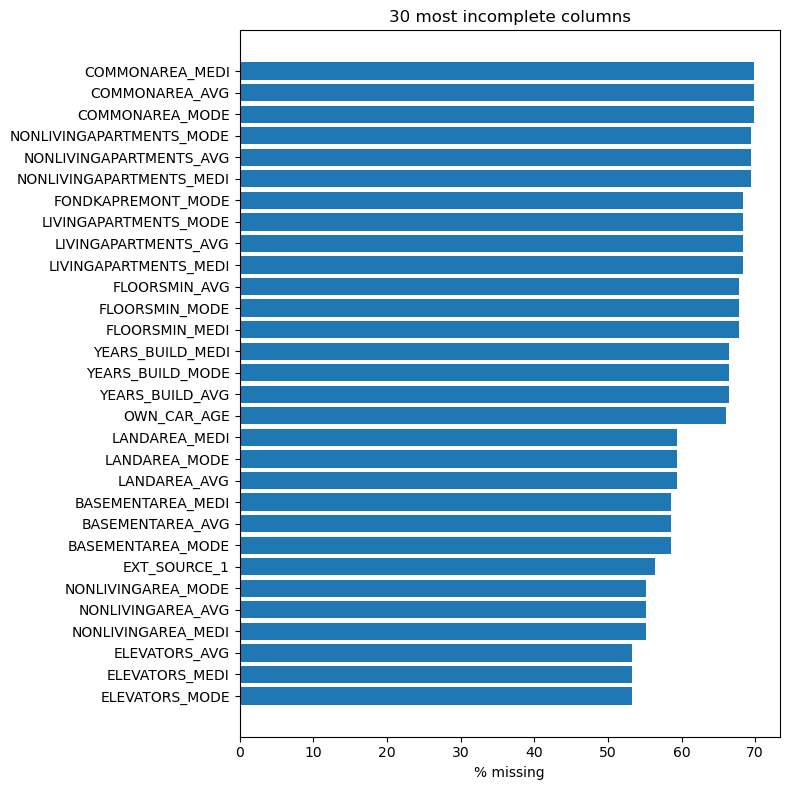

In [8]:
top30 = missing["missing_pct"].head(30).sort_values()

plt.figure(figsize=(8, 8))
plt.barh(top30.index, top30.values)
plt.title("30 most incomplete columns")
plt.xlabel("% missing")
plt.tight_layout()
plt.show()

**67 columns have missing values and 41 are more than 50% empty**, mostly the housing block (`COMMONAREA_*`, `FLOORSMIN_*`). `EXT_SOURCE_1` (56% missing) is the important one because it is a strong predictor.

# 3. Target and class imbalance

In [9]:
print(df["TARGET"].value_counts(normalize=True).round(4))

ratio = (df["TARGET"] == 0).sum() / (df["TARGET"] == 1).sum()
print(f"Class imbalance ratio: {ratio:.1f} : 1")

TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64
Class imbalance ratio: 11.4 : 1


**8.07% of applicants defaulted (1 : 11.4).** A model predicting "no default" for everyone is 92% accurate, so we use AUROC/AUPRC and `class_weight="balanced"`.

# 4. Default rate by segment
Segments with fewer than 500 applicants are left out so tiny groups don't top the list.

In [10]:
cols = ["NAME_CONTRACT_TYPE", "NAME_INCOME_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE"]

for col in cols:
    print(f"=== default rate by {col} ===")
    summary = (
        df.groupby(col)["TARGET"]
          .agg(default_rate="mean", count="size")
          .sort_values("default_rate", ascending=False)
    )
    print(summary)
    print()


=== default rate by NAME_CONTRACT_TYPE ===
                    default_rate   count
NAME_CONTRACT_TYPE                      
Cash loans              0.083459  278232
Revolving loans         0.054783   29279

=== default rate by NAME_INCOME_TYPE ===
                      default_rate   count
NAME_INCOME_TYPE                          
Maternity leave           0.400000       5
Unemployed                0.363636      22
Working                   0.095885  158774
Commercial associate      0.074843   71617
State servant             0.057550   21703
Pensioner                 0.053864   55362
Businessman               0.000000      10
Student                   0.000000      18

=== default rate by OCCUPATION_TYPE ===
                       default_rate  count
OCCUPATION_TYPE                           
Low-skill Laborers         0.171524   2093
Drivers                    0.113261  18603
Waiters/barmen staff       0.112760   1348
Security staff             0.107424   6721
Laborers              

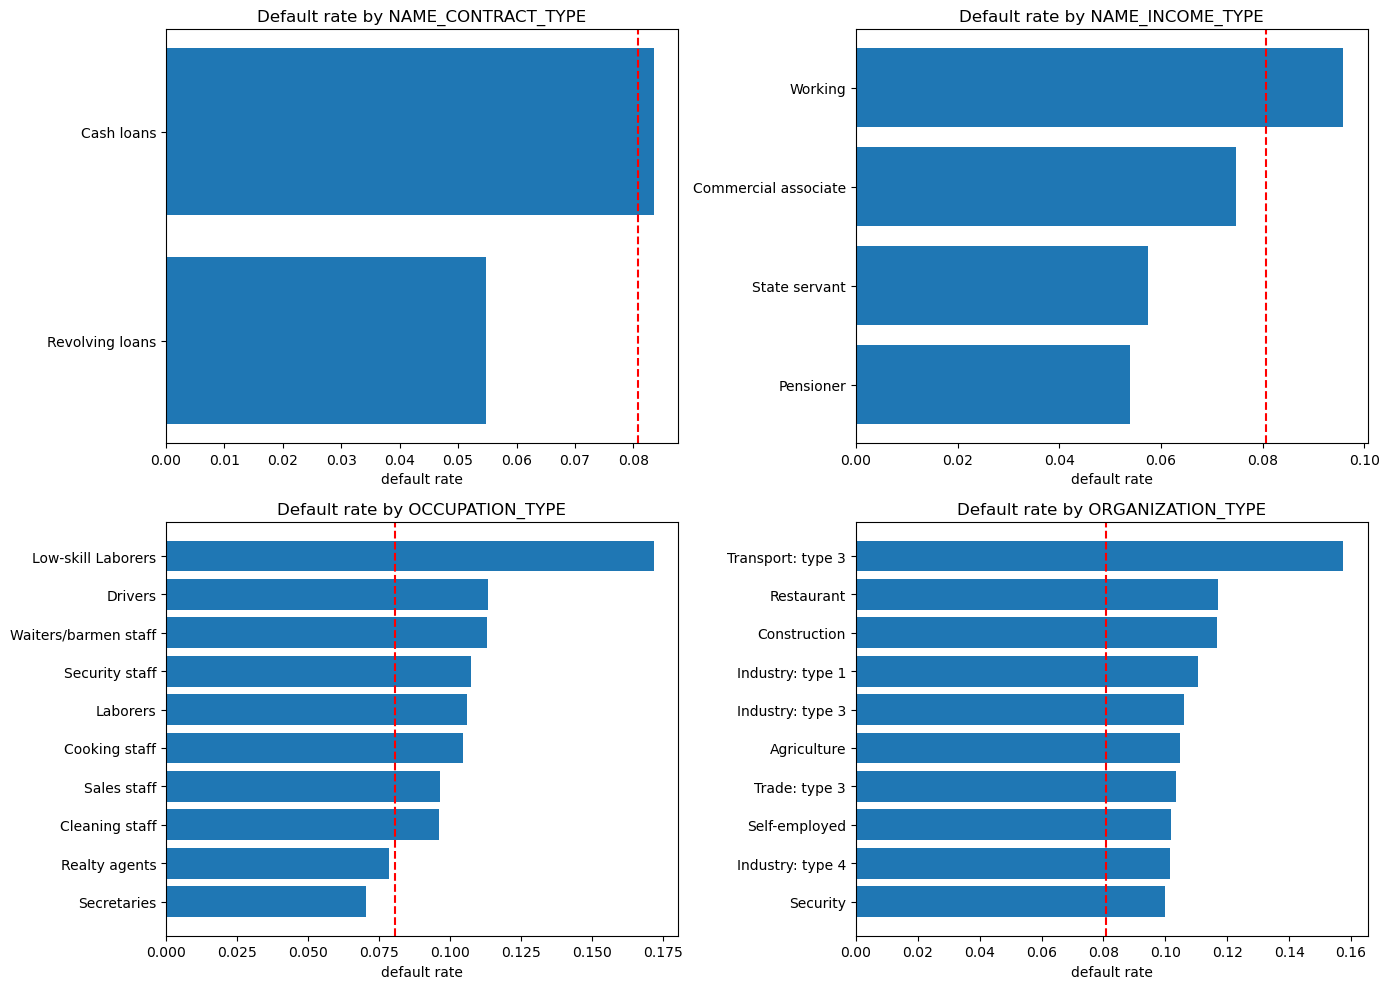

In [11]:
    
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), cols):
    rate = (df.groupby(col)["TARGET"].agg(["mean", "size"])
              .query("size >= 500")["mean"].sort_values().tail(10))
    ax.barh(rate.index, rate.values)
    ax.axvline(df["TARGET"].mean(), color="red", linestyle="--")
    ax.set_title(f"Default rate by {col}")
    ax.set_xlabel("default rate")
plt.tight_layout()
plt.show()

**Cash loans default more than revolving loans (8.3% vs 5.5%).** Low-skill laborers (17.2%), drivers and waiters (~11%) are the riskiest occupations; unemployed and maternity-leave applicants are higher still but too few to trust.

# 5. Distribution plots

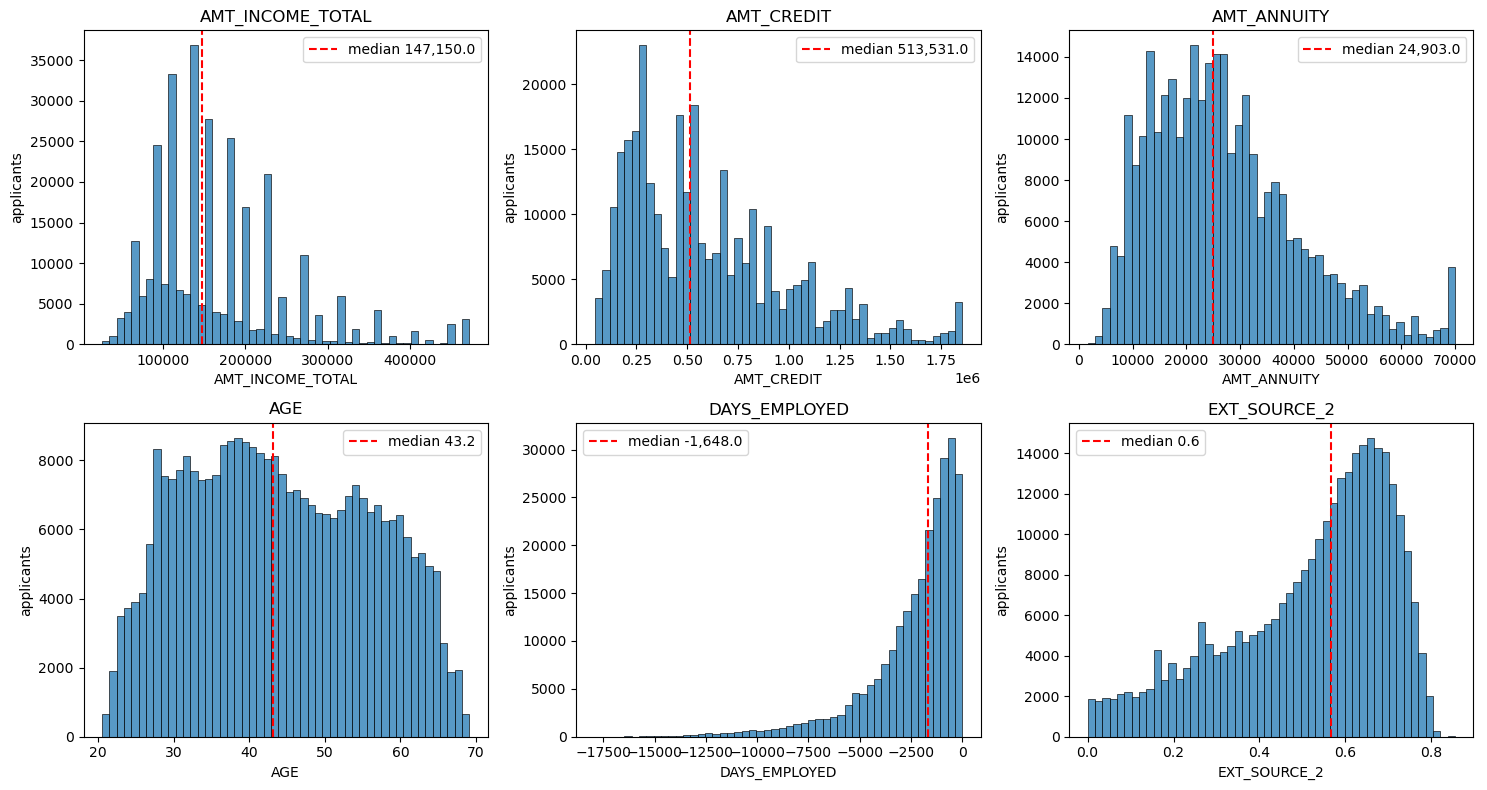

In [12]:
df["AGE"] = -df["DAYS_BIRTH"] / 365
features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AGE", "DAYS_EMPLOYED", "EXT_SOURCE_2"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feature in zip(axes.ravel(), features):
    data = df[feature].dropna()
    if feature.startswith("AMT_"):
        data = data.clip(upper=data.quantile(0.99))
    if feature == "DAYS_EMPLOYED":
        data = data[data != 365243]
    sns.histplot(data, ax=ax, bins=50)
    ax.axvline(data.median(), color="red", linestyle="--", label=f"median {data.median():,.1f}")
    ax.set_title(feature)
    ax.set_ylabel("applicants")
    ax.legend()
plt.tight_layout()
plt.show()

**Income, credit and annuity are right-skewed** (median income 147,150 vs a max of 117M), so we impute with the median. Age is fairly symmetric around 43, and `EXT_SOURCE_2` is already on a 0–1 scale.

# 6. Correlation with TARGET

EXT_SOURCE_3                  -0.179
EXT_SOURCE_2                  -0.160
EXT_SOURCE_1                  -0.155
AGE                           -0.078
DAYS_BIRTH                     0.078
REGION_RATING_CLIENT_W_CITY    0.061
REGION_RATING_CLIENT           0.059
DAYS_LAST_PHONE_CHANGE         0.055
DAYS_ID_PUBLISH                0.051
REG_CITY_NOT_WORK_CITY         0.051
FLAG_EMP_PHONE                 0.046
DAYS_EMPLOYED                 -0.045
REG_CITY_NOT_LIVE_CITY         0.044
FLAG_DOCUMENT_3                0.044
FLOORSMAX_AVG                 -0.044
Name: TARGET, dtype: float64


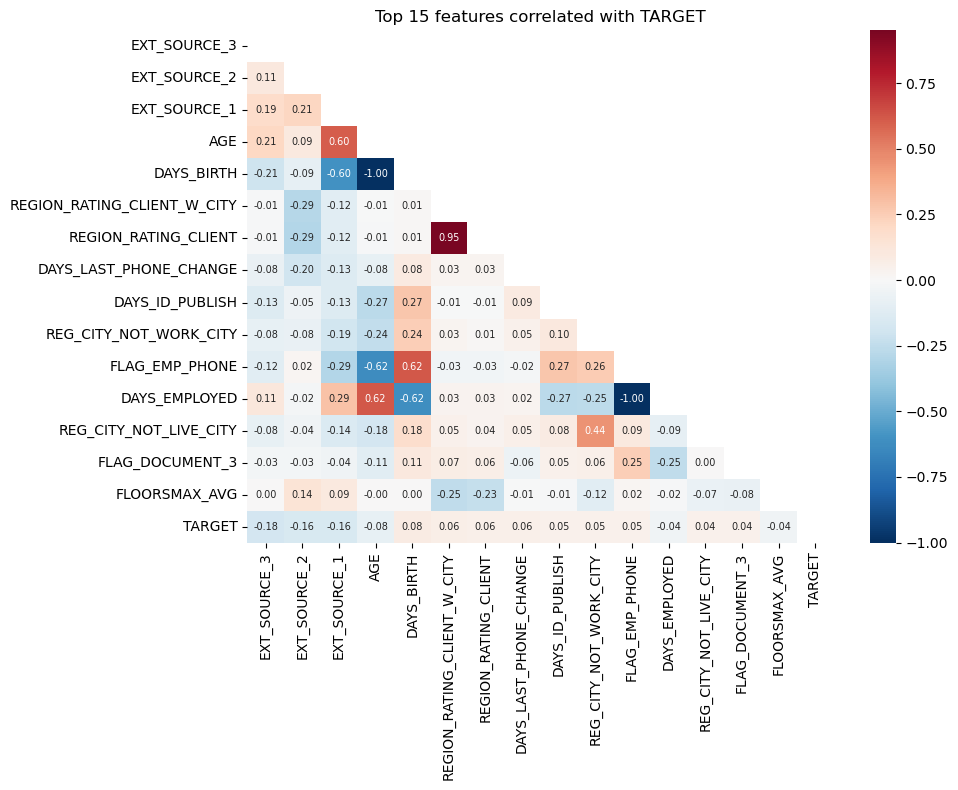

In [13]:
numeric_df = df.select_dtypes(include="number").drop(columns=["SK_ID_CURR"])
target_corr = numeric_df.corr()["TARGET"].drop("TARGET")
top15 = target_corr.abs().sort_values(ascending=False).head(15).index
print(target_corr[top15].round(3))

corr = numeric_df[list(top15) + ["TARGET"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, annot_kws={"size": 7})
plt.title("Top 15 features correlated with TARGET")
plt.tight_layout()
plt.show()

**The three external scores are the strongest signals** (−0.18, −0.16, −0.16): higher score, lower risk. Age is next (younger applicants default more). Some pairs are duplicates (`AGE`/`DAYS_BIRTH`, the two region ratings), which only matters for the linear model.

# 7. Bureau records per applicant

bureau.csv: (1716428, 17)


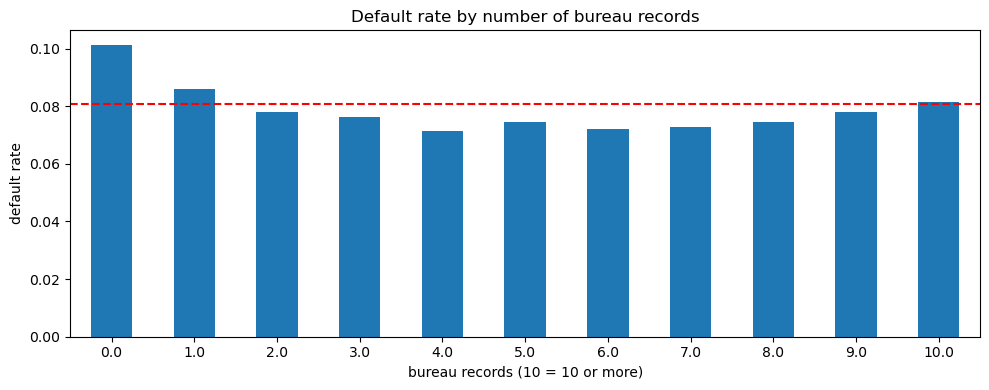

In [14]:
bureau = pd.read_csv("../data/bureau.csv")
print("bureau.csv:", bureau.shape)

bureau_count = bureau.groupby("SK_ID_CURR").size().rename("num_bureau_records")
df = df.merge(bureau_count, on="SK_ID_CURR", how="left")
df["num_bureau_records"] = df["num_bureau_records"].fillna(0)

bureau_rate = df.groupby(df["num_bureau_records"].clip(upper=10))["TARGET"].mean()

plt.figure(figsize=(10, 4))
bureau_rate.plot(kind="bar")
plt.axhline(df["TARGET"].mean(), color="red", linestyle="--")
plt.title("Default rate by number of bureau records")
plt.xlabel("bureau records (10 = 10 or more)")
plt.ylabel("default rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**U-shaped:** applicants with no bureau history default at 10.1% (nothing to score them on), the rate drops to ~7% at 4–6 records and rises again at 10+. So the bureau count is useful, and "no history" deserves its own flag.

# Executive summary
- 307,511 applications, **8.07% default** → heavy imbalance, accuracy is not a usable metric.
- **Missing data is common** (67 columns) but mostly in housing fields; `EXT_SOURCE_1` is the important exception.
- **`DAYS_EMPLOYED = 365243`** is a placeholder for pensioners/unemployed (18% of rows).
- **External bureau scores are by far the strongest signal**; age, occupation, contract type and bureau history add smaller signal.